# FIE463 – Numerical Methods in Macroeconomics and Finance  
## Term Paper 2

---
<div style="margin-top: 30px;">

**Candidate numbers:** XXX  
Norwegian School of Economics (NHH)

</div>
---

<div style="margin-top: 40px; font-size: 14px; color: gray;">
Artificial intelligence tools (ChatGPT, openAI) have been used for support in this assignment. The tool has been used for code clarification, debugging, and improving language and structure. All analysis, implementation, and final solutions are our own work.
</div>

# Part 1 — Data preprocessing (SCE)

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import validation_curve, GridSearchCV

## 1. Import and merge SCE data
Loading all files and combine them into a single dataset

In [2]:
files = glob.glob("sce_extract_*.csv")

df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

print(f"Total observations: {len(df)}")

Total observations: 180268


## 2. Forward fill variables

Some variables are only observed in the first survey wave, we therefpre forward-fill these variables within individuals 

In [3]:
df = df.sort_values(["userid", "date"])

#only filling individual characteristics
cols_to_fill = [
    "age_init", "female", "educ", "hh_inc_bin",
    "num_kids", "owner"
] 

df[cols_to_fill] = df.groupby("userid")[cols_to_fill].ffill()

## 3. Drop observations from 2025

We exclude observations from 2025 to avoid the volatility generated by the second Trump administration

In [4]:
# converting date to datetime
df["date"] = pd.to_datetime(df["date"])

before = len(df)

df = df[df["date"] < "2025-01-01"]

print(f"Dropped {before - len(df)} observations")

Dropped 4167 observations


## 4. Drop missing values

We remove observations with missing values for the selected variables

In [5]:
variables = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up"
]

before = len(df)

df = df.dropna(subset=variables)

after = len(df)

print(f"Observations before dropna: {before}")
print(f"Observations after dropna: {after}")
print(f"Dropped {before - after} observations (missing values)")


Observations before dropna: 176101
Observations after dropna: 174324
Dropped 1777 observations (missing values)


## 5. Removing outliers

Winsorizing extreme values by keeping observations between the 1st and 99th percentiles

In [6]:
# before trimming
before = len(df)

# create mask (true/false)
mask = pd.Series(True, index=df.index)

for var in variables:
    p1 = df[var].quantile(0.01)
    p99 = df[var].quantile(0.99)
    
    mask &= (df[var] > p1) & (df[var] < p99)

# apply mask
df = df[mask].copy()

# after trimming
after = len(df)

print(f"Observations before trimming: {before}")
print(f"Observations after trimming: {after}")
print(f"Dropped {before - after} observations (outliers)")

Observations before trimming: 174324
Observations after trimming: 159630
Dropped 14694 observations (outliers)


## 6. Creating indicator variables

Constructing binary indicators capturing optimism about unemployment, stocks, and house prices

In [7]:
df["optimist_unrate"] = (df["prob_unrate_up"] < 50).astype(int)
df["optimist_stocks"] = (df["prob_stocks_up"] > 50).astype(int)
df["optimist_house_price"] = (df["house_price_change"] > 0).astype(int)

## 7. Summary statistics

Reporting the key dataset characteristics after cleaning 

In [8]:
print(f"Observations: {len(df):,}")
print(f"Survey periods: {df['wid'].nunique():,}")

print(f"Start date: {df['date'].min().strftime('%Y-%m')}")
print(f"End date:   {df['date'].max().strftime('%Y-%m')}")

Observations: 159,630
Survey periods: 139
Start date: 2013-06
End date:   2024-12


# Part 2 — Data preprocessing (macro/finance)

In the second part, we augment the SCE dataset with macroeconomic and financial tdata from Yahoo Finance and FRED. To avoid look-ahead bias, we ensure that only information available at the time of each survey is used when merging the data. We then construct additional variables capturing changes in the data (e.g., monthly differences).


Note: the data from Yahoo finance was downloaded using the yfinance package

## Choice of macroeconomic variables

We include a set of macroeconomic and financial variables that capture key drivers of household expectations across financial markets, inflation, and the real economy.

The S&P 500 and oil prices proxy for financial conditions and input cost shocks, while CPI and the unemployment rate capture inflation and labor market conditions that are directly relevant for households. The federal funds rate and mortgage rate reflect monetary policy and borrowing conditions, which influence both economic activity and housing expectations.

These variables are chosen as they are widely recognized, high-frequency indicators with clear economic interpretation and direct relevance for household beliefs, unlike more complex or less observable measures. All variables are included in lagged form to ensure that only information available at the time of the survey is used, thereby avoiding look-ahead bias.

## Loading macroeconomi and financial data

In [9]:
# Yahoo (skipping two rows)
sp500    = pd.read_csv("sp500.csv")
oil      = pd.read_csv("oil.csv")

# FRED
cpi      = pd.read_csv("cpi.csv")
unrate   = pd.read_csv("unrate.csv")
fedfunds = pd.read_csv("fedfunds.csv")
mortgage = pd.read_csv("mortgage.csv")

## Cleaning Yahoo and FRED data

Yahoo Finance data contains extra header rows that we remove and FRED data is cleaned by renaming columns for consistency. Removing spaces and standardize lowercase. We then convert dates to datetime and then year-month, making us able to merge on month and not excact date. Also lagging the variables to ensure that only past information is usead to avoid look-ahead bias.

In [10]:
## cleaning yahoo
sp500 = sp500.iloc[:, [0, 4]]
oil   = oil.iloc[:, [0, 4]]

# remove first two rows (Ticker, Date)
sp500 = sp500.iloc[2:]
oil   = oil.iloc[2:]

# rename columns
sp500.columns = ["date", "sp500"]
oil.columns   = ["date", "oil"]

# convert to numeric
sp500["sp500"] = pd.to_numeric(sp500["sp500"], errors="coerce")
oil["oil"]     = pd.to_numeric(oil["oil"], errors="coerce")

In [11]:
# cleaning FRED standardising column names
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

unrate = unrate.rename(columns={
    "observation_date": "date",
    "UNRATE": "unrate"
})

fedfunds = fedfunds.rename(columns={
    "observation_date": "date",
    "FEDFUNDS": "fedfunds"
})

mortgage = mortgage.rename(columns={
    "observation_date": "date",
    "MORTGAGE30US": "mortgage"
})

In [12]:
# convert date columns todatetime
for d in [sp500, oil, cpi, unrate, fedfunds, mortgage]:
    d["date"] = pd.to_datetime(d["date"])

In [13]:
# aggregate yahoo data to monthly
sp500 = sp500.sort_values("date")
oil   = oil.sort_values("date")

# convert to monthly, last observation in month
sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
oil   = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()

/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_43547/321765930.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_43547/321765930.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  oil   = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()


In [14]:
# add year_month period column to all datasets
for d in [df, sp500, oil, cpi, unrate, fedfunds, mortgage]:
    d["year_month"] = d["date"].dt.to_period("M")

In [15]:
# aggregate macro data to monthly 
sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
oil = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
cpi = cpi.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
unrate = unrate.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
fedfunds = fedfunds.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
mortgage = mortgage.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()

/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_43547/3532056791.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500 = sp500.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_43547/3532056791.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  oil = oil.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_43547/3532056791.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cpi = cpi.groupby(pd.Grouper(key="date", freq="M")).last().reset_index()
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_43547/3532056791.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  unrate = unrate.groupby(pd.Grouper(key="date"

In [16]:
# ensure oil has full monthly coverage 
full_index = pd.period_range(
    start=oil["year_month"].min(),
    end=oil["year_month"].max(),
    freq="M"
)

oil = oil.set_index("year_month").reindex(full_index)
oil.index.name = "year_month"
oil = oil.reset_index()
oil["oil"] = oil["oil"].ffill()

In [17]:
# create lagged variables (lag by 1 month to avoid look-ahead bias)
sp500["sp500_lag"] = sp500["sp500"].shift(1)
oil["oil_lag"] = oil["oil"].shift(1)
cpi["cpi_lag"] = cpi["cpi"].shift(1)
unrate["unrate_lag"] = unrate["unrate"].shift(1)
fedfunds["fedfunds_lag"] = fedfunds["fedfunds"].shift(1)
mortgage["mortgage_lag"] = mortgage["mortgage"].shift(1)

In [18]:
# merge lagged macro variables into main SCE dataframe
df = df.merge(sp500[["year_month", "sp500_lag"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_lag"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_lag"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_lag"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_lag"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_lag"]], on="year_month", how="left")

# Part 3 - Exploratory data analysis (SCE)

In the third part, we look at the  distribution and time evolution of  expectation variables in the SCE data. We visualize their distributions using histograms and examine how their average values and the share of optimistic households evolve over time.

## 1. Distribution of expectations

We begin by examining the distribution of responses for each expectations variable

In [19]:
# variables of interest
variables = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

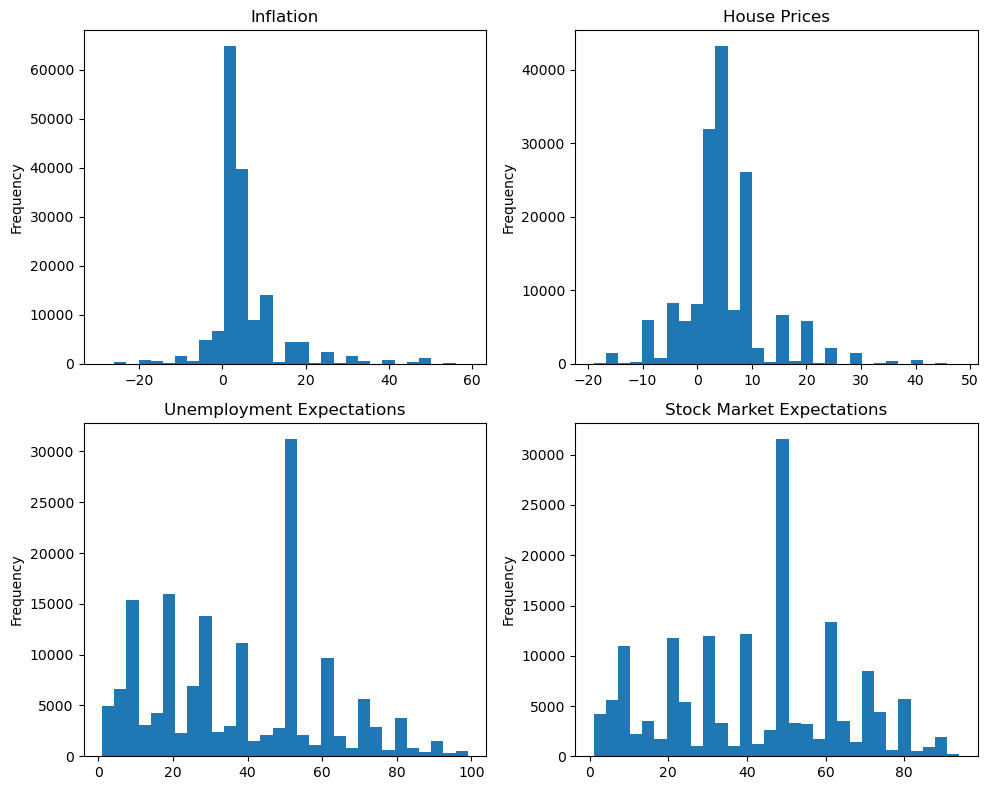

In [20]:
# titles
titles = {
    "infl_1y": "Inflation",
    "house_price_change": "House Prices",
    "prob_unrate_up": "Unemployment Expectations",
    "prob_stocks_up": "Stock Market Expectations"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# plot
for i, var in enumerate(variables):
    axes[i].hist(df[var], bins=30)
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")  # remove variable name on x-axis
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The histograms show that most households expect low inflation and positive house price growth, although there are some extreme values. Expectations about unemployment and the stock market are spread between 0 and 100, but many responses are clustered around 50, indicating uncertainty. 

## 2. Average expectations over time


In [21]:
# group by month and take mean
df_grouped = df.groupby("year_month")[variables].mean()

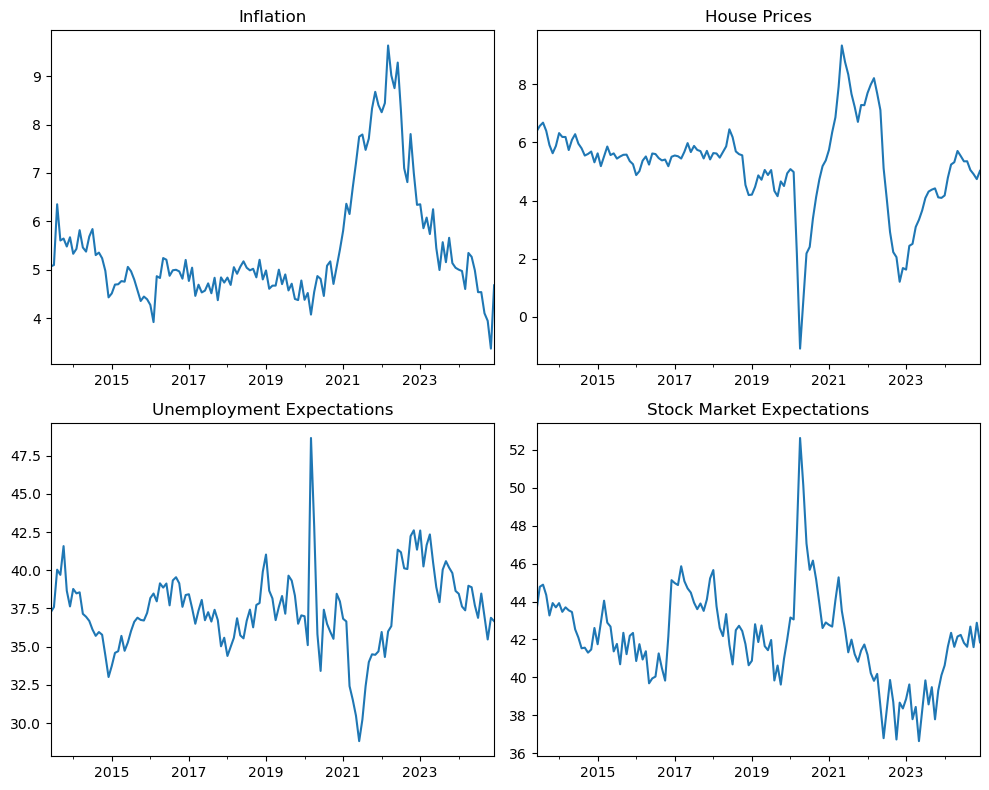

In [22]:
# titles
titles = {
    "infl_1y": "Inflation",
    "house_price_change": "House Prices",
    "prob_unrate_up": "Unemployment Expectations",
    "prob_stocks_up": "Stock Market Expectations"
}

# plot 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    df_grouped[var].plot(ax=axes[i])
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")  # cleaner
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

The time series show that inflation expectations (infl_1y) were relatively stable before increasing sharply around 2021–2022, followed by a decline. This likely reflects changing macroeconomic conditions during this period.

House price expectations (house_price_change) display more volatility, with a strong drop around 2020 and a sharp increase afterward, before stabilizing again.

The probability of higher unemployment (prob_unrate_up) fluctuates over time, with noticeable spikes during periods of economic uncertainty, suggesting that households adjust expectations in response to shocks.

Similarly, expectations about stock market increases (prob_stocks_up) vary over time, with a clear peak around 2020–2021 and a decline afterward, indicating changing sentiment in financial markets.

## 3. Share of optimistic households

In [23]:
# grouping by month and calculating mean for the two selected variables
optimist_vars = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]

df_opt = df.groupby("year_month")[optimist_vars].mean()

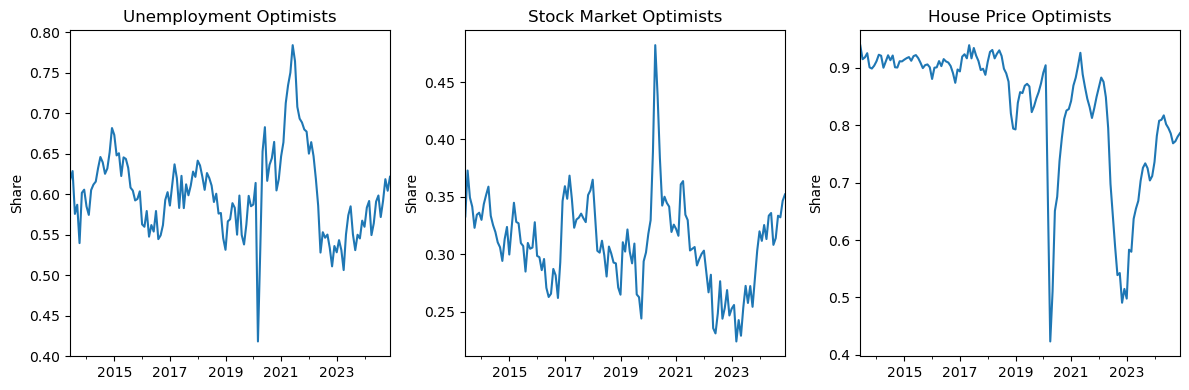

In [24]:
# titles
titles = {
    "optimist_unrate": "Unemployment Optimists",
    "optimist_stocks": "Stock Market Optimists",
    "optimist_house_price": "House Price Optimists"
}

# plot 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for i, var in enumerate(optimist_vars):
    df_opt[var].plot(ax=axes[i])
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Share")

plt.tight_layout()
plt.show()

The share of optimistic households fluctuates over time across all three measures, with noticeable variation around key macroeconomic periods. This indicates that expectations are sensitive to economic conditions.

All three series display similar dynamics, suggesting that optimism about unemployment, the stock market, and house prices tends to move together over time.

# Task 4 - Exploratory data analysis (macro/finance)

In task 4 we examine how macroeconomic variables help explain household expectations. Again, we use lagged macro variables to avoid look ahead bias

## 1. Figure showing the time series of the original variables in levels

In [25]:
macro_vars = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]

df_levels = df.groupby("year_month")[macro_vars].mean(numeric_only=True)

# standardize to fit in one model
df_levels_std = (df_levels - df_levels.mean()) / df_levels.std()

<Figure size 10000x5000 with 0 Axes>

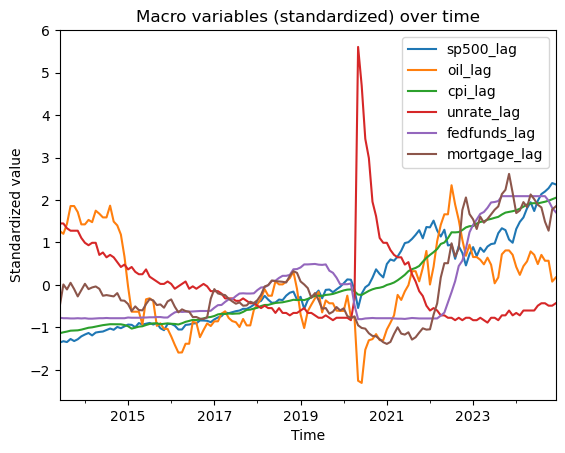

In [26]:
# plot
plt.figure(figsize=(100, 50)) 
df_levels_std.plot()
plt.title("Macro variables (standardized) over time")
plt.xlabel("Time")
plt.ylabel("Standardized value")
plt.show()

The standardized level plot shows the evolution of macroeconomic variables over time while allowing for better comparison across series with different scales. The S&P 500 exhibits a strong upward trend, while variables such as inflation, unemployment, and interest rates remain relatively stable. Standardization makes it easier to compare movements across variables that would otherwise differ significantly in magnitude.

## 2. Changes in macro variables

In [27]:
# create month-over-month change variables
sp500["sp500_change"] = sp500["sp500"].diff()
oil["oil_change"] = oil["oil"].diff()
cpi["cpi_change"] = cpi["cpi"].diff()
unrate["unrate_change"] = unrate["unrate"].diff()
fedfunds["fedfunds_change"] = fedfunds["fedfunds"].diff()
mortgage["mortgage_change"] = mortgage["mortgage"].diff()

# merge change variables into df
df = df.merge(sp500[["year_month", "sp500_change"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_change"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_change"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_change"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_change"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_change"]], on="year_month", how="left")

In [28]:
macro_changes = ["sp500_change", "oil_change", "cpi_change", "unrate_change", "fedfunds_change", "mortgage_change"]

df_changes = df.groupby("year_month")[macro_changes].mean(numeric_only=True)

df_changes_std = (df_changes - df_changes.mean()) / df_changes.std()

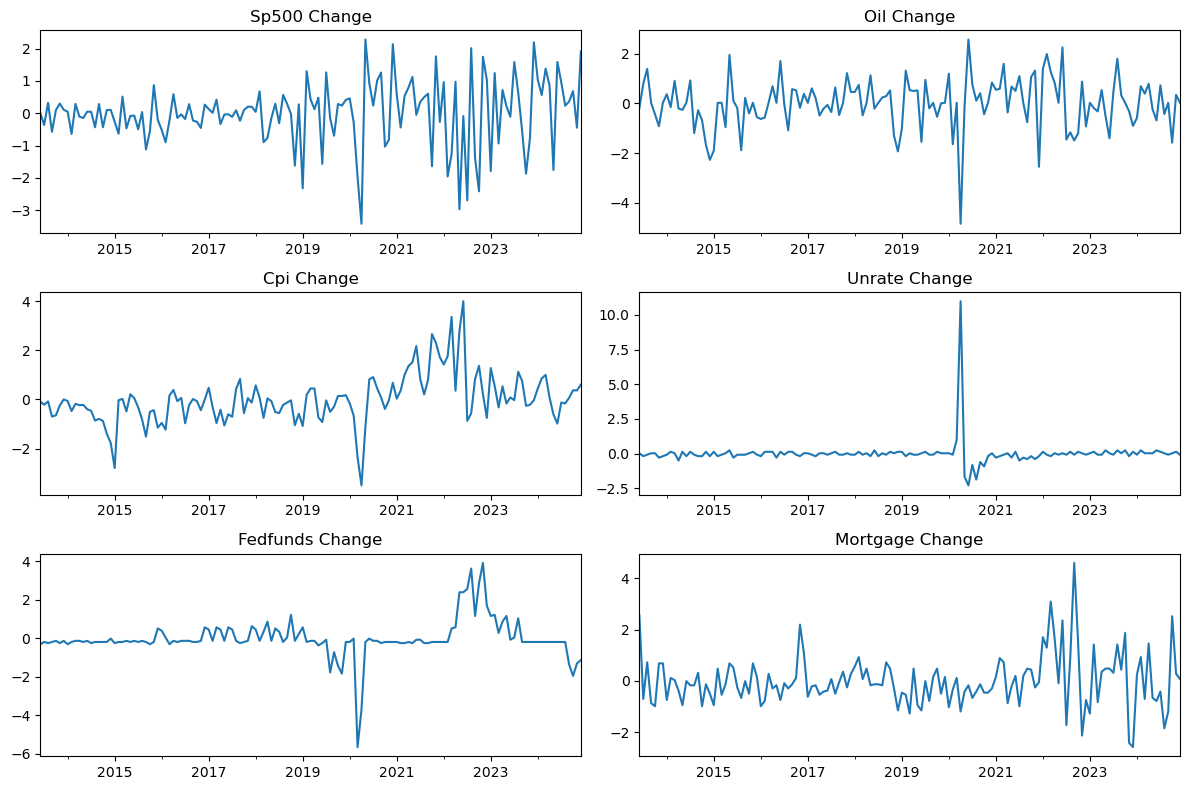

In [29]:
# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(macro_changes):
    df_changes_std[var].plot(ax=axes[i])
    axes[i].set_title(var.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Correlation between macro varaibles and expectation variables

In [30]:
expectation_vars = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

macro_all = macro_vars + macro_changes

In [31]:
# table
for var in expectation_vars:
    
    corr = df[macro_all + [var]].corr()[var].drop(var)
    corr = corr.sort_values(key=abs, ascending=False)  # viktig!
    
    corr_table = corr.to_frame(name="Correlation")
    
    print(f"\nCorrelation with {var}:")
    display(corr_table.round(3))


Correlation with infl_1y:


,Correlation
cpi_change,0.091
oil_lag,0.065
fedfunds_change,0.060
sp500_lag,0.057
cpi_lag,0.047
mortgage_change,0.043
oil_change,0.027
fedfunds_lag,-0.025
sp500_change,-0.015
unrate_change,-0.010



Correlation with house_price_change:


,Correlation
fedfunds_lag,-0.082
mortgage_lag,-0.076
cpi_change,0.061
oil_change,0.057
cpi_lag,-0.054
unrate_change,-0.048
oil_lag,0.025
mortgage_change,0.024
sp500_lag,-0.014
fedfunds_change,-0.013



Correlation with prob_unrate_up:


,Correlation
mortgage_lag,0.055
fedfunds_lag,0.045
unrate_lag,-0.032
unrate_change,0.031
sp500_change,-0.029
cpi_lag,0.025
cpi_change,-0.024
oil_lag,0.021
oil_change,-0.017
fedfunds_change,0.009



Correlation with prob_stocks_up:


,Correlation
unrate_lag,0.057
cpi_lag,-0.049
mortgage_lag,-0.049
fedfunds_change,-0.047
fedfunds_lag,-0.042
sp500_lag,-0.038
oil_lag,-0.034
cpi_change,-0.031
unrate_change,0.021
mortgage_change,-0.016


The correlations between macro variables and expectations are generally very small, suggesting limited explanatory power. A few weak patterns emerge: inflation expectations (infl_1y) are slightly positively correlated with oil prices and stock market levels, while house price expectations are weakly negatively related to interest rates (fed funds and mortgage rates). Overall, the results indicate that individual expectations are only weakly related to aggregate macroeconomic conditions.

# Part 5 - Predicting continuous expectation variables

We split the data into a training sample (before 2024) and a test sample (2024). Thereafter, estimate Linear Regression, Ridge, and Lasso models using lagged macroeconomic variables. The models are then extanded to include individual variables.  

In [32]:
# saving results
results_reg = []
results_clf = []

## 1. Split data

In [33]:
# split data
df_train = df[df["date"] < "2024-01-01"]
df_test  = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]

print(f"Training observations: {len(df_train)}")
print(f"Test observations: {len(df_test)}")

Training observations: 147874
Test observations: 11756


## 2. Define varaibles

In [34]:
# features
target_vars     = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]
X_macro         = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]
X_individual    = ["age_init", "educ", "hh_inc_bin", "female"]
alphas          = np.logspace(-3, 3, 20)

In [35]:
# linear regression
for y_var in target_vars:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_reg.append({
            "Target":    y_var,
            "Model":     "Linear Regression",
            "Features":  feature_set,
            "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            "Test R2":   round(r2_score(y_test, y_pred), 3),
        })

## Ridge regression

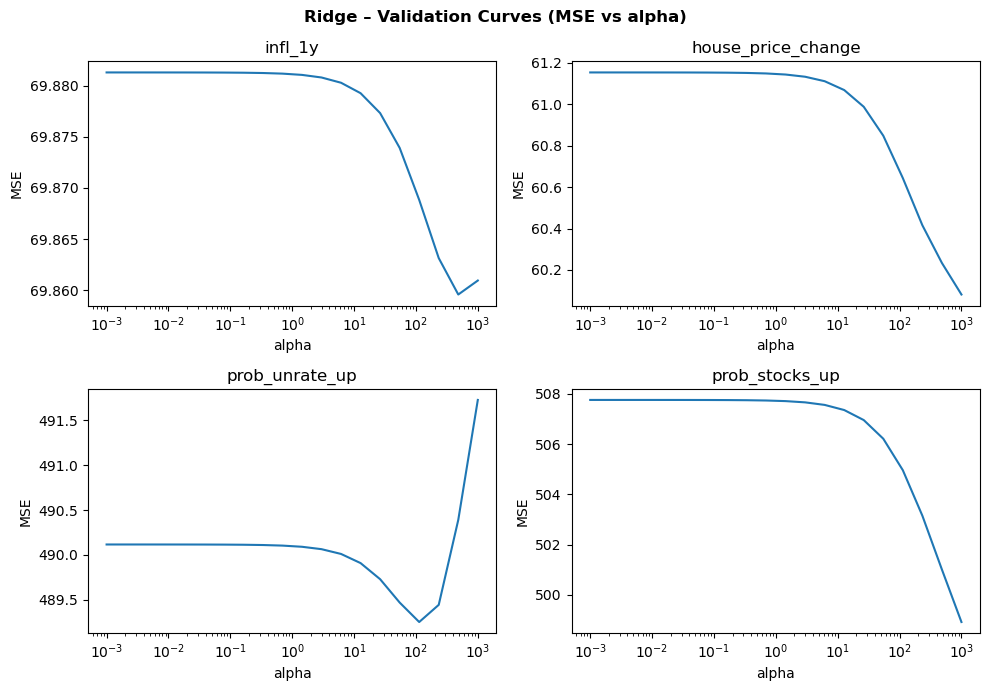

In [36]:
# validation curve
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Ridge – Validation Curves (MSE vs alpha)", fontweight="bold")
axes = axes.flatten()

for i, y_var in enumerate(target_vars):
    train = df_train[X_macro + [y_var]].dropna()
    X_sc  = StandardScaler().fit_transform(train[X_macro])
    y     = train[y_var]

    _, val_scores = validation_curve(
        Ridge(), X_sc, y,
        param_name="alpha", param_range=alphas,
        scoring="neg_mean_squared_error", cv=5
    )

    axes[i].plot(alphas, -val_scores.mean(axis=1))
    axes[i].set_xscale("log")
    axes[i].set_title(y_var)
    axes[i].set_xlabel("alpha")
    axes[i].set_ylabel("MSE")

plt.tight_layout()
plt.show()


In [37]:
# Ridge loop
for y_var in target_vars:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", RidgeCV(alphas=alphas, cv=5))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_reg.append({
            "Target":    y_var,
            "Model":     "Ridge",
            "Features":  feature_set,
            "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            "Test R2":   round(r2_score(y_test, y_pred), 3),
        })

## Lasso regression

In [38]:
# loop
from sklearn.linear_model import Lasso

for y_var in target_vars:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", LassoCV(cv=5))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_reg.append({
            "Target":    y_var,
            "Model":     "Lasso",
            "Features":  feature_set,
            "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            "Test R2":   round(r2_score(y_test, y_pred), 3),
        })

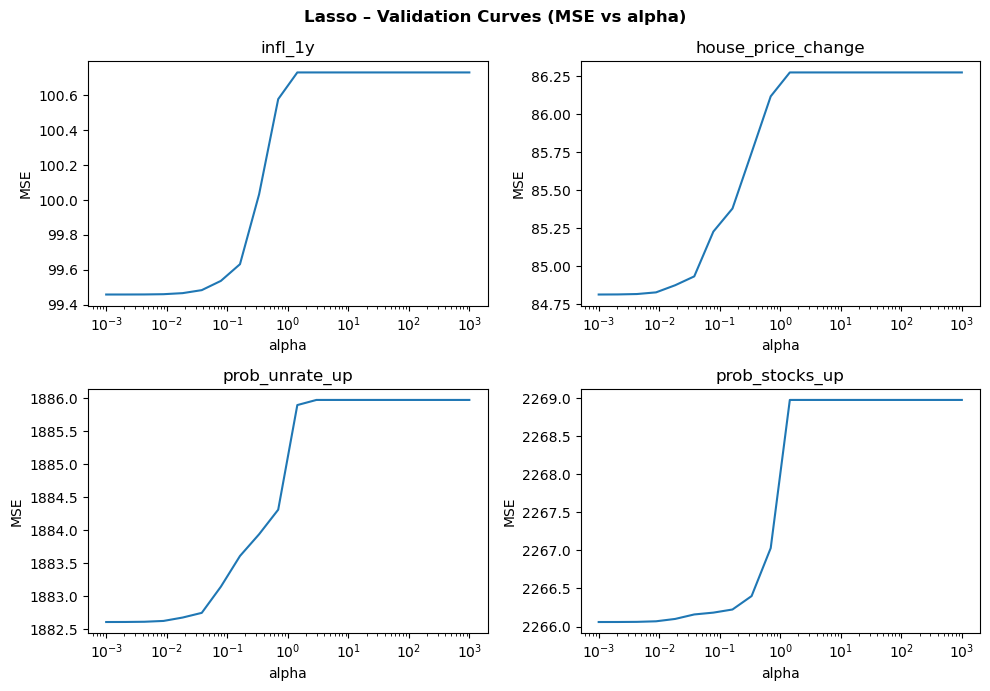

In [39]:
# validation curve
from sklearn.linear_model import lasso_path

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Lasso – Validation Curves (MSE vs alpha)", fontweight="bold")
axes = axes.flatten()

for i, y_var in enumerate(target_vars):
    train = df_train[X_macro + [y_var]].dropna()
    X_sc  = StandardScaler().fit_transform(train[X_macro])
    y     = train[y_var].values

    alphas_path, coefs, _ = lasso_path(X_sc, y, alphas=alphas)

    # beregn MSE manuelt
    mse = []
    for coef in coefs.T:
        y_pred = X_sc @ coef
        mse.append(mean_squared_error(y, y_pred))

    axes[i].plot(alphas_path, mse)
    axes[i].set_xscale("log")
    axes[i].set_title(y_var)
    axes[i].set_xlabel("alpha")
    axes[i].set_ylabel("MSE")

plt.tight_layout()
plt.show()

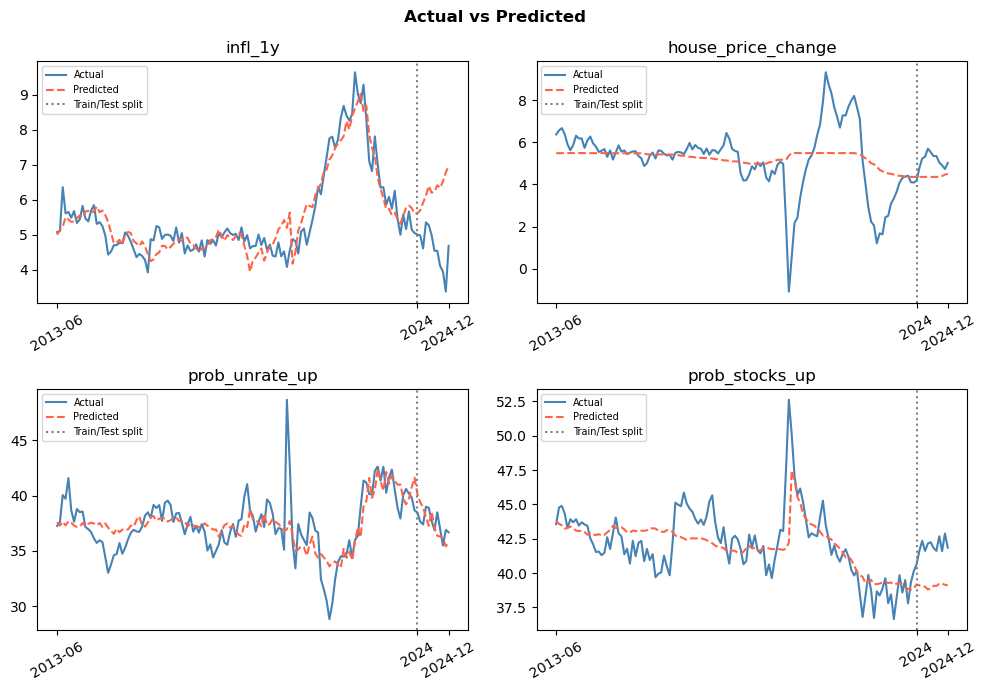

In [40]:
# actual vs predicted
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Actual vs Predicted", fontweight="bold")
axes = axes.flatten()

for i, y_var in enumerate(target_vars):
    train = df_train[X_macro + [y_var]].dropna()
    test  = df_test[X_macro  + [y_var]].dropna()

    pipe = Pipeline([("scaler", StandardScaler()), ("model", LassoCV(cv=5))])
    pipe.fit(train[X_macro], train[y_var])

    train = train.copy()
    test  = test.copy()
    train["pred"]       = pipe.predict(train[X_macro])
    test["pred"]        = pipe.predict(test[X_macro])
    train["year_month"] = df_train.loc[train.index, "year_month"]
    test["year_month"]  = df_test.loc[test.index,  "year_month"]

    tr = train.groupby("year_month")[[y_var, "pred"]].mean()
    te = test.groupby("year_month")[[y_var,  "pred"]].mean()

    combined = pd.concat([tr, te])
    x        = range(len(combined))
    split    = len(tr)

    axes[i].plot(x, combined[y_var],   label="Actual",    color="steelblue")
    axes[i].plot(x, combined["pred"],  label="Predicted", color="tomato", linestyle="--")
    axes[i].axvline(x=split, color="gray", linestyle=":", label="Train/Test split")
    axes[i].set_xticks([0, split, len(combined)-1])
    axes[i].set_xticklabels([str(combined.index[0]), "2024", str(combined.index[-1])], rotation=30)
    axes[i].set_title(y_var)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [41]:
# save data
pd.DataFrame(results_reg)

,Target,Model,Features,Test RMSE,Test R2
0,infl_1y,Linear Regression,Macro only,9.380,-0.035
1,infl_1y,Linear Regression,Macro + Individual,9.203,0.005
2,house_price_change,Linear Regression,Macro only,8.494,-0.012
3,house_price_change,Linear Regression,Macro + Individual,8.359,0.020
4,prob_unrate_up,Linear Regression,Macro only,22.350,-0.003
5,prob_unrate_up,Linear Regression,Macro + Individual,22.080,0.020
6,prob_stocks_up,Linear Regression,Macro only,23.044,-0.007
7,prob_stocks_up,Linear Regression,Macro + Individual,21.968,0.084
8,infl_1y,Ridge,Macro only,9.383,-0.035
9,infl_1y,Ridge,Macro + Individual,9.210,0.004


# Part 6 - Predicting binary optimism variables

In this part, We used Logistic Regression to predict three binary optimism indicators. Since the share of optimists is around 60% in the data, a naive model will always predicts the majority class will achieve approximately 58% accuracy. We therefore report balanced accuracy alongside 
standard accuracy.

## Defining variables

In [42]:
target_vars_clf = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]
X_macro         = ["sp500_lag", "oil_lag", "cpi_lag", "unrate_lag", "fedfunds_lag", "mortgage_lag"]
X_individual    = ["age_init", "educ", "hh_inc_bin", "female"]

### Logistic regression

In [43]:
# logistic regression
results_clf = []

for y_var in target_vars_clf:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars  + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(class_weight="balanced", max_iter=1000))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_clf.append({
            "Target":            y_var,
            "Model":             "Logistic Regression",
            "Features":          feature_set,
            "Accuracy":          round(accuracy_score(y_test, y_pred), 3),
            "Balanced Accuracy": round(balanced_accuracy_score(y_test, y_pred), 3),
        })

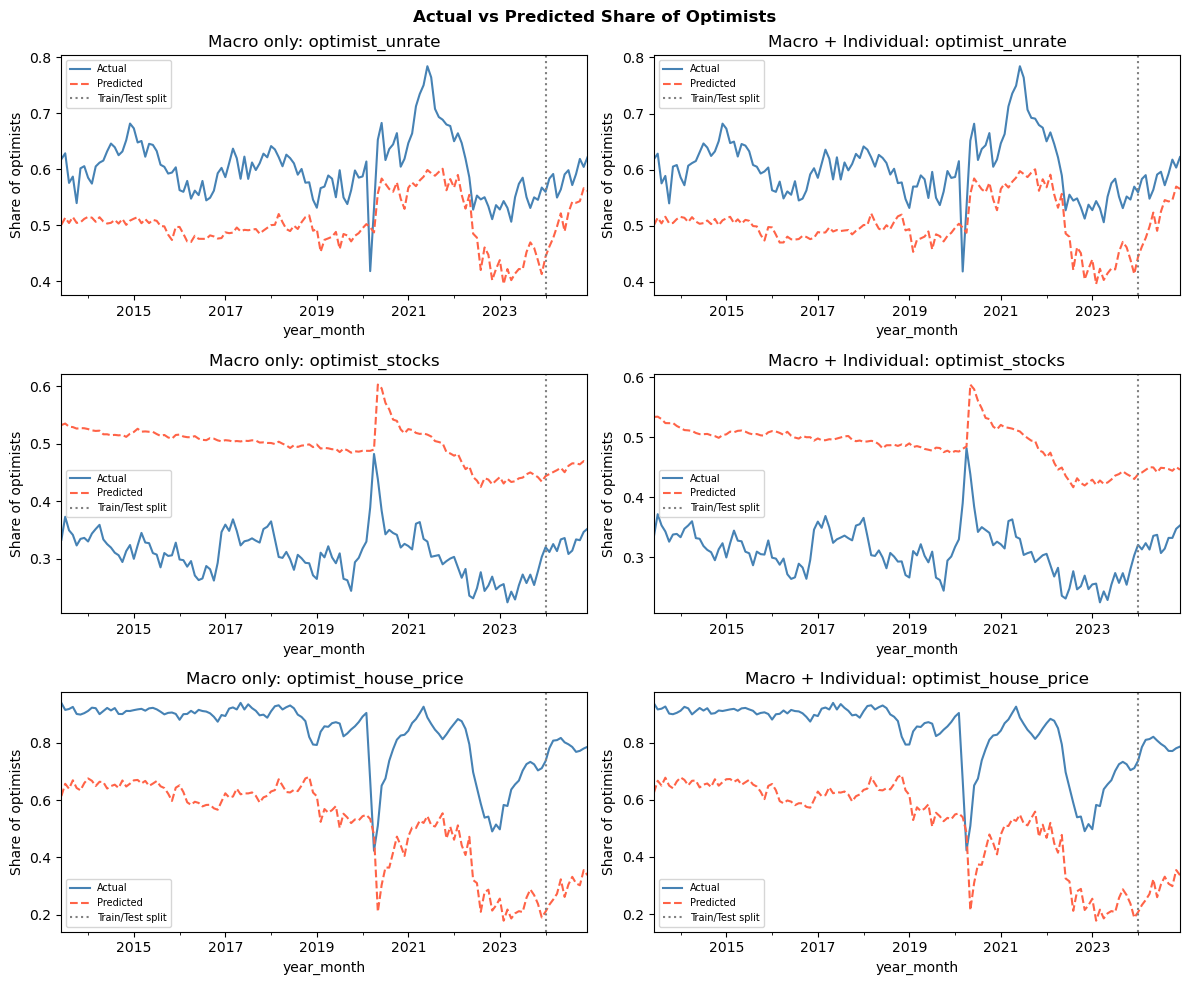

In [44]:
# actual vs predicted share of optimists
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle("Actual vs Predicted Share of Optimists", fontweight="bold")

for i, y_var in enumerate(target_vars_clf):
    for j, (feature_set, X_vars) in enumerate([("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]):

        train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
        test  = df_test[X_vars  + [y_var, "year_month"]].dropna().copy()

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  LogisticRegression(class_weight="balanced", max_iter=1000))
        ])
        pipe.fit(train[X_vars], train[y_var])

        train["pred"] = pipe.predict_proba(train[X_vars])[:, 1]
        test["pred"]  = pipe.predict_proba(test[X_vars])[:, 1]

        tr = train.groupby("year_month")[[y_var, "pred"]].mean()
        te = test.groupby("year_month")[[y_var,  "pred"]].mean()

        combined   = pd.concat([tr, te])
        split_date = str(te.index[0])

        ax = axes[i, j]
        combined[y_var].plot(ax=ax, label="Actual",    color="steelblue")
        combined["pred"].plot(ax=ax, label="Predicted", color="tomato", linestyle="--")
        ax.axvline(x=split_date, color="gray", linestyle=":", label="Train/Test split")
        ax.set_title(f"{feature_set}: {y_var}")
        ax.set_ylabel("Share of optimists")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [45]:
# classification results
pd.DataFrame(results_clf)

,Target,Model,Features,Accuracy,Balanced Accuracy
0,optimist_unrate,Logistic Regression,Macro only,0.521,0.510
1,optimist_unrate,Logistic Regression,Macro + Individual,0.554,0.536
2,optimist_stocks,Logistic Regression,Macro only,0.673,0.500
3,optimist_stocks,Logistic Regression,Macro + Individual,0.663,0.616
4,optimist_house_price,Logistic Regression,Macro only,0.213,0.500
5,optimist_house_price,Logistic Regression,Macro + Individual,0.212,0.500


# Part 7 -  Conclusion

This paper has examined the predictability of household expectations from the Survey of Consumer 
Expectations (SCE) using a combination of macroeconomic variables and individual-level 
characteristics. We estimated models for four continuous expectation variables (infl_1y, 
house_price_change, prob_unrate_up, prob_stocks_up) and three binary optimism indicators 
(optimist_unrate, optimist_stocks, optimist_house_price), using data up to end of 2023 for 
training and 2024 as the test period.

## Continous expectation variablesn (from part 5)
All models struggled to predict individual expectations out of sample. R² values 
were close to zero across most targets, which is consistent with the weak correlations 
we found in Part 4.

The best results were for stock market expectations (prob_stocks_up), where Ridge with 
macro and individual features reached R² of 0.083. For inflation and unemployment 
expectations, R² stayed below 0.025 regardless of model or feature set. Lasso performed 
worse than Linear Regression and Ridge for house price expectations.

Adding individual variables (age, education, income, gender) consistently improved 
performance, but the gains were small. Ridge and Linear Regression performed similarly 
across most targets.

## Binary optimism variables (from part 6)
For the binary optimism variables, logistic regression achieved modest results. For 
optimist_unrate, balanced accuracy was 0.507 with macro only and 0.535 with individual 
variables. For optimist_stocks, balanced accuracy improved from 0.500 to 0.614 when individual variables were added, which was the largest improvement across all targets. For optimist_house_price, balanced accuracy stayed at 0.500 regardless of feature set.

## Overall
Household expectations are difficult to predict. The best results were for stock market 
expectations, both for the continuous variable (R² 0.083) and the binary indicator 
(balanced accuracy 0.614). Individual variables helped in most cases, but the overall 
predictive power remained low across all models and targets.s

In [46]:
# regression results
pd.DataFrame(results_reg)

,Target,Model,Features,Test RMSE,Test R2
0,infl_1y,Linear Regression,Macro only,9.380,-0.035
1,infl_1y,Linear Regression,Macro + Individual,9.203,0.005
2,house_price_change,Linear Regression,Macro only,8.494,-0.012
3,house_price_change,Linear Regression,Macro + Individual,8.359,0.020
4,prob_unrate_up,Linear Regression,Macro only,22.350,-0.003
5,prob_unrate_up,Linear Regression,Macro + Individual,22.080,0.020
6,prob_stocks_up,Linear Regression,Macro only,23.044,-0.007
7,prob_stocks_up,Linear Regression,Macro + Individual,21.968,0.084
8,infl_1y,Ridge,Macro only,9.383,-0.035
9,infl_1y,Ridge,Macro + Individual,9.210,0.004


In [47]:
# classification results
pd.DataFrame(results_clf)

,Target,Model,Features,Accuracy,Balanced Accuracy
0,optimist_unrate,Logistic Regression,Macro only,0.521,0.510
1,optimist_unrate,Logistic Regression,Macro + Individual,0.554,0.536
2,optimist_stocks,Logistic Regression,Macro only,0.673,0.500
3,optimist_stocks,Logistic Regression,Macro + Individual,0.663,0.616
4,optimist_house_price,Logistic Regression,Macro only,0.213,0.500
5,optimist_house_price,Logistic Regression,Macro + Individual,0.212,0.500
